# Feature Engineering (GCP Spark on YARN)
- Time bin: 30 minutes
- Target: pickup_demand_t1 (t+1 bin)
- Train/val/test: 70/10/20 from pre-split HDFS folders
- Exclude outliers: 2020-03 to 2020-06

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline

BASE_HDFS = "/user/tiennd3886"
RAW_TRAIN = "/user/data/train/*.parquet"
RAW_VAL = "/user/data/val/*.parquet"
RAW_TEST = "/user/data/test/*.parquet"

OUT_DENSE = f"{BASE_HDFS}/feature_engineering/demand_prediction_dense_30m"
OUT_FEATURES = f"{BASE_HDFS}/feature_engineering/demand_prediction_features_30m"

BIN_SECONDS = 1800
BIN_COL = "pickup_bin_30m"
ZONE_COL = "PULocationID"
TARGET_COL = "pickup_demand_t1"
CURRENT_COL = "pickup_demand"

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering_GCP")
    .master("yarn")
    .config("spark.submit.deployMode", "client")
    .config("spark.eventLog.enabled", "true")
    .config("spark.executor.instances", "3")
    .config("spark.executor.cores", "3")
    .config("spark.executor.memory", "8g")
    .config("spark.executor.memoryOverhead", "1g")
    .config("spark.driver.memory", "3g")
    .config("spark.driver.memoryOverhead", "1g")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.sql.parquet.mergeSchema", "true")
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .getOrCreate()
 )
spark.sparkContext.setLogLevel("WARN")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/25 13:40:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/25 13:40:26 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


In [2]:
PICKUP_COL_CANDIDATES = ["tpep_pickup_datetime", "pickup_datetime"]

from functools import reduce

def load_split(path_glob: str, split_name: str):
    sc = spark.sparkContext
    fs = sc._jvm.org.apache.hadoop.fs.FileSystem.get(sc._jsc.hadoopConfiguration())
    FileStatus_arr = fs.globStatus(sc._jvm.org.apache.hadoop.fs.Path(path_glob))
    if not FileStatus_arr:
        raise ValueError(f"No files found for {path_glob}")
    file_paths = [status.getPath().toString() for status in FileStatus_arr]
    
    dfs = []
    for p in file_paths:
        df = spark.read.parquet(p)
        pickup_col = next((c for c in PICKUP_COL_CANDIDATES if c in df.columns), None)
        if pickup_col is None or ZONE_COL not in df.columns:
            print(f"Skipping {p} due to missing columns")
            continue
        cleaned = (
            df.select(
                F.to_timestamp(F.col(pickup_col)).alias("pickup_ts"),
                F.col(ZONE_COL).cast("int").alias(ZONE_COL),
            )
            .where(F.col("pickup_ts").isNotNull())
            .where(F.col(ZONE_COL).isNotNull())
            .where(F.col(ZONE_COL) > 0)
            .withColumn("split", F.lit(split_name))
        )
        cleaned = cleaned.where(F.year("pickup_ts").between(2020, 2025))
        cleaned = cleaned.where(~((F.year("pickup_ts") == 2020) & (F.month("pickup_ts").between(3, 6))))
        dfs.append(cleaned)
        
    if not dfs:
        raise ValueError(f"No valid data to union for {split_name}")
    
    return reduce(lambda a, b: a.unionByName(b), dfs)

train_df = load_split(RAW_TRAIN, "train")
val_df = load_split(RAW_VAL, "val")
test_df = load_split(RAW_TEST, "test")
raw_df = train_df.unionByName(val_df).unionByName(test_df).cache()
print("Raw rows:", raw_df.count())


Raw rows: 219267313


In [3]:
demand = (
    raw_df
    .withColumn(
        BIN_COL,
        F.to_timestamp(
            F.from_unixtime(
                F.floor(F.unix_timestamp(F.col("pickup_ts")) / BIN_SECONDS) * BIN_SECONDS
            )
        ),
    )
    .groupBy("split", ZONE_COL, BIN_COL)
    .agg(F.count(F.lit(1)).cast("double").alias(CURRENT_COL))
    .cache()
 )

zone_dim = demand.select(ZONE_COL).distinct()
split_bounds = demand.groupBy("split").agg(F.min(BIN_COL).alias("min_ts"), F.max(BIN_COL).alias("max_ts"))
time_dim = (
    split_bounds
    .select("split", F.sequence(F.col("min_ts"), F.col("max_ts"), F.expr("interval 30 minutes")).alias("bins"))
    .select("split", F.explode(F.col("bins")).alias(BIN_COL))
 )

dense_df = (
    zone_dim.crossJoin(time_dim)
    .join(demand, on=["split", ZONE_COL, BIN_COL], how="left")
    .fillna({CURRENT_COL: 0.0})
    .repartition(96)
    .cache()
 )
print("Dense rows:", dense_df.count())

Dense rows: 27684169


In [4]:
train_dense = dense_df.where(F.col("split") == "train")
zone_profiles = (
    train_dense
    .withColumn("bin_idx", (F.hour(BIN_COL) * 2 + (F.minute(BIN_COL) / 30)).cast("int"))
    .groupBy(ZONE_COL, "bin_idx")
    .agg(F.avg(CURRENT_COL).alias("avg_demand"))
    .groupBy(ZONE_COL)
    .pivot("bin_idx")
    .agg(F.first("avg_demand"))
    .fillna(0.0)
 )

assembler = VectorAssembler(inputCols=[str(i) for i in range(48)], outputCol="raw_features")
scaler = StandardScaler(inputCol="raw_features", outputCol="features_scaled", withStd=True, withMean=False)
kmeans = KMeans(k=6, seed=42, featuresCol="features_scaled")
pipeline = Pipeline(stages=[assembler, scaler, kmeans])
cluster_model = pipeline.fit(zone_profiles)
clusters = cluster_model.transform(zone_profiles).select(ZONE_COL, F.col("prediction").cast("double").alias("cluster_id"))

dense_df = dense_df.join(clusters, on=ZONE_COL, how="left")

w = Window.partitionBy("split", ZONE_COL).orderBy(BIN_COL)
w_hist_12 = w.rowsBetween(-12, -1)
w_hist_48 = w.rowsBetween(-48, -1)

features_df = (
    dense_df
    .withColumn("hour", F.hour(BIN_COL).cast("double"))
    .withColumn("dow", F.dayofweek(BIN_COL).cast("double"))
    .withColumn("month", F.month(BIN_COL).cast("double"))
    .withColumn("is_weekend", F.when(F.dayofweek(BIN_COL).isin([1, 7]), F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("lag_6", F.lag(CURRENT_COL, 6).over(w).cast("double"))
    .withColumn("lag_12", F.lag(CURRENT_COL, 12).over(w).cast("double"))
    .withColumn("lag_336", F.lag(CURRENT_COL, 336).over(w).cast("double"))
    .withColumn("roll_mean_12", F.avg(CURRENT_COL).over(w_hist_12).cast("double"))
    .withColumn("roll_mean_48", F.avg(CURRENT_COL).over(w_hist_48).cast("double"))
    .withColumn("roll_std_48", F.stddev_pop(CURRENT_COL).over(w_hist_48).cast("double"))
    .withColumn(TARGET_COL, F.lead(CURRENT_COL, 1).over(w).cast("double"))
    .dropna()
    .cache()
 )
print("Feature rows:", features_df.count())

26/05/25 13:46:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/05/25 13:46:30 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Feature rows: 27418276


Saved HDFS outputs:
- /user/tiennd3886/feature_engineering/demand_prediction_dense_30m
- /user/tiennd3886/feature_engineering/demand_prediction_features_30m


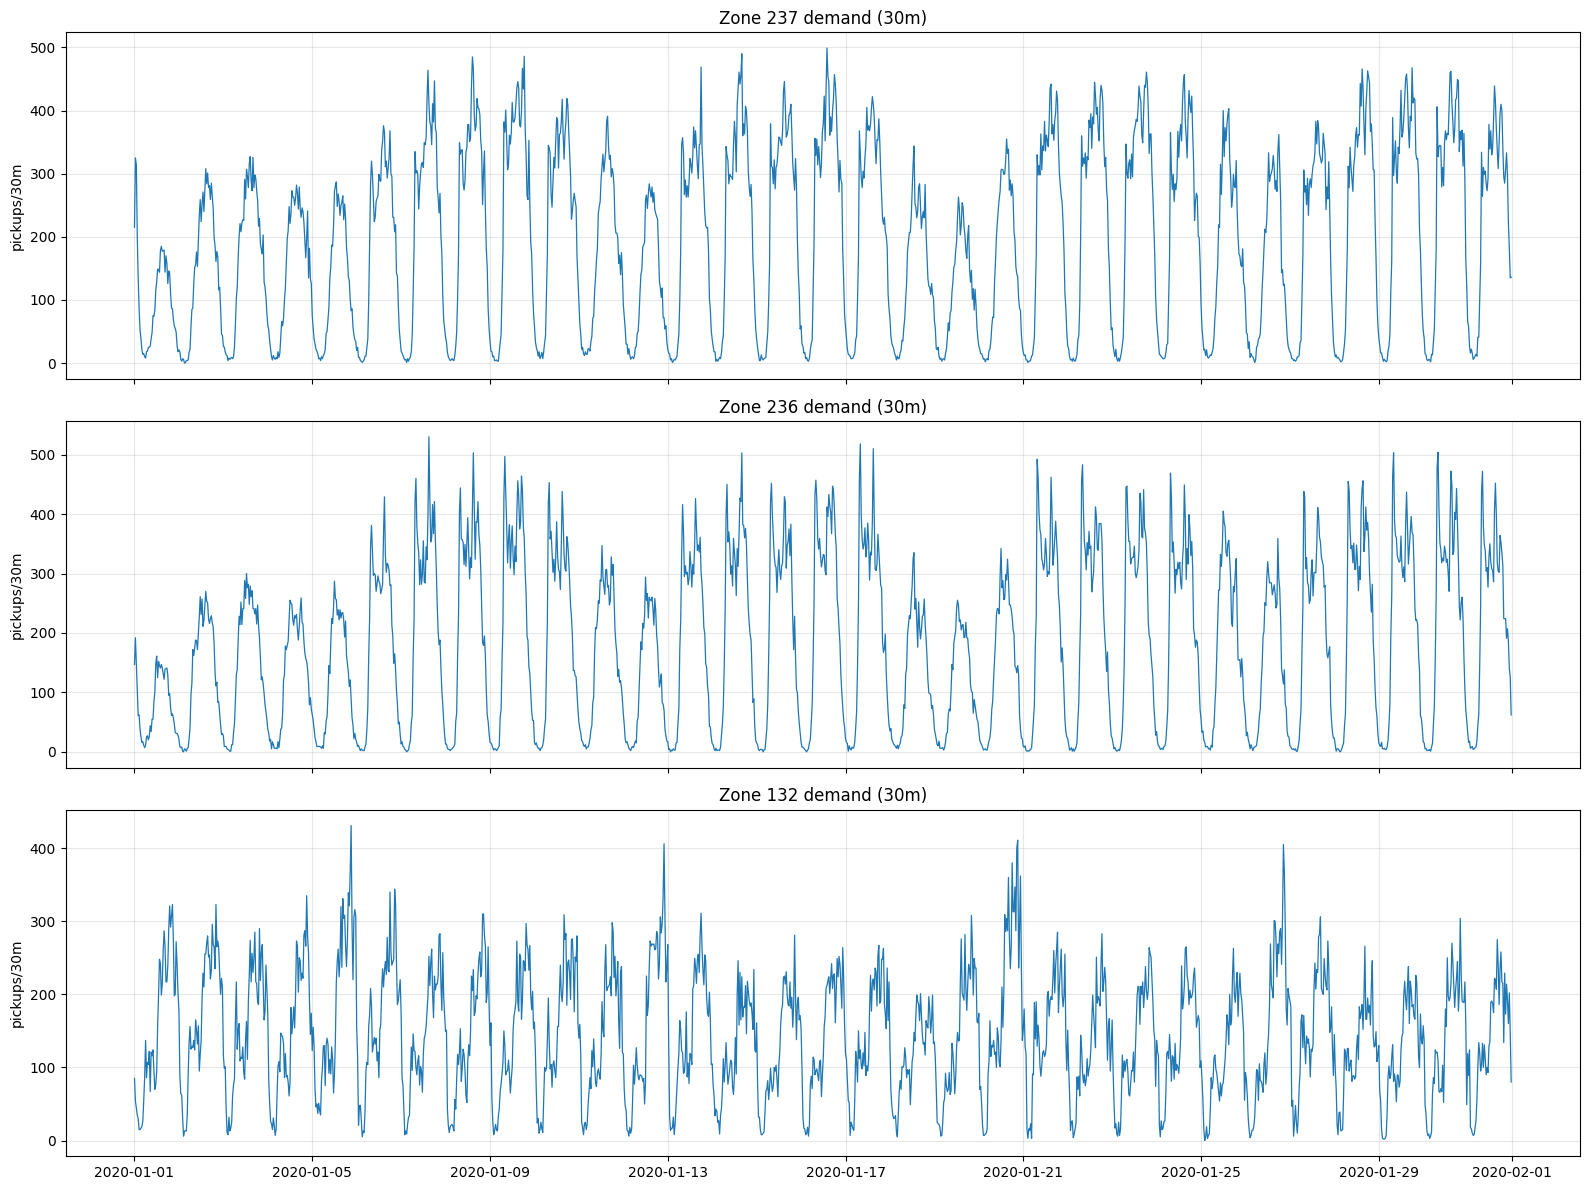

In [5]:
dense_df.write.mode("overwrite").parquet(OUT_DENSE)
features_df.write.mode("overwrite").parquet(OUT_FEATURES)
print("Saved HDFS outputs:")
print("-", OUT_DENSE)
print("-", OUT_FEATURES)

zone_rank = (
    train_dense.groupBy(ZONE_COL).agg(F.sum(CURRENT_COL).alias("total"))
    .orderBy(F.col("total").desc()).limit(3)
 )
top_zones = [r[ZONE_COL] for r in zone_rank.collect()]
plot_df = (
    train_dense.where(F.col(ZONE_COL).isin(top_zones))
    .where(F.col(BIN_COL) < F.lit("2020-02-01"))
    .orderBy(ZONE_COL, BIN_COL).toPandas()
 )
if len(plot_df) > 0:
    fig, axes = plt.subplots(len(top_zones), 1, figsize=(16, 4 * len(top_zones)), sharex=True)
    if len(top_zones) == 1:
        axes = [axes]
    for ax, z in zip(axes, top_zones):
        tmp = plot_df[plot_df[ZONE_COL] == z]
        ax.plot(tmp[BIN_COL], tmp[CURRENT_COL], linewidth=0.9)
        ax.set_title(f"Zone {z} demand (30m)")
        ax.set_ylabel("pickups/30m")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

spark.catalog.clearCache()
spark.stop()

In [6]:
spark.catalog.clearCache()
spark.stop()